Antes de decidir qué analizar, hay que ver qué hay. Este cuaderno se va llenando de a un paso por vez.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RUTA = "../data/raw/"

ventas = pd.read_csv(RUTA + "train.csv", parse_dates=["date"])

print(f"{len(ventas):,} filas y {ventas.shape[1]} columnas")
print(f"Del {ventas.date.min():%d/%m/%Y} al {ventas.date.max():%d/%m/%Y}")

3,000,888 filas y 6 columnas
Del 01/01/2013 al 15/08/2017


## 1. Los primeros 30 registros

Una fila es la venta de una familia de producto, en una tienda, en un día.

In [2]:
ventas.head(30)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


## 2. Qué productos existen

El dataset no tiene productos individuales: los agrupa en **familias**.

In [3]:
familias = ventas.family.unique()

print(len(familias), "familias de producto:")
for f in sorted(familias):
    print(" -", f)

33 familias de producto:
 - AUTOMOTIVE
 - BABY CARE
 - BEAUTY
 - BEVERAGES
 - BOOKS
 - BREAD/BAKERY
 - CELEBRATION
 - CLEANING
 - DAIRY
 - DELI
 - EGGS
 - FROZEN FOODS
 - GROCERY I
 - GROCERY II
 - HARDWARE
 - HOME AND KITCHEN I
 - HOME AND KITCHEN II
 - HOME APPLIANCES
 - HOME CARE
 - LADIESWEAR
 - LAWN AND GARDEN
 - LINGERIE
 - LIQUOR,WINE,BEER
 - MAGAZINES
 - MEATS
 - PERSONAL CARE
 - PET SUPPLIES
 - PLAYERS AND ELECTRONICS
 - POULTRY
 - PREPARED FOODS
 - PRODUCE
 - SCHOOL AND OFFICE SUPPLIES
 - SEAFOOD


## 3. Las ventas a lo largo del tiempo

Suma de las ventas de todas las tiendas y familias, día a día.

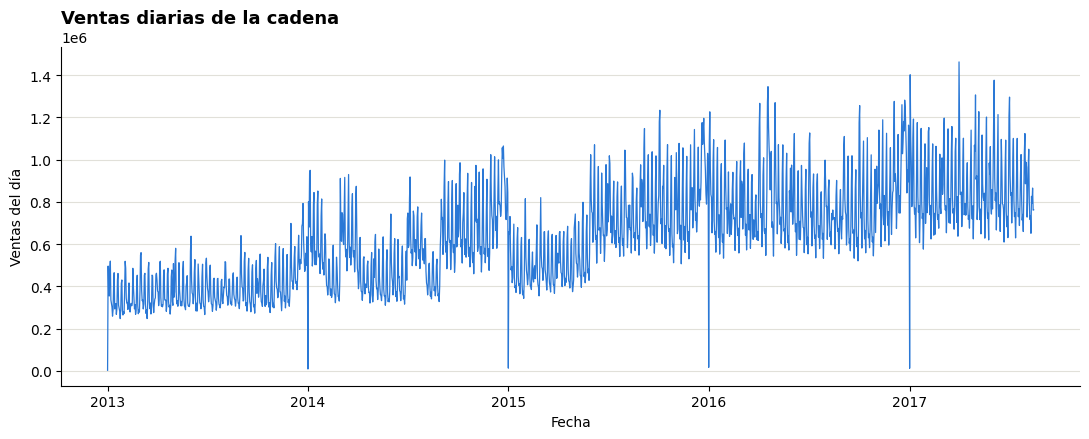

In [4]:
por_fecha = ventas.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(por_fecha.index, por_fecha.values, linewidth=0.9, color="#2a78d6")

ax.set_title("Ventas diarias de la cadena", loc="left", fontsize=13, fontweight="600")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas del día")
ax.grid(axis="y", color="#e1e0d9")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()